## 1. Setup

### 1.1 Imports

In [1]:
import torch
import torch.nn.functional as F

from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import math

### 1.2 Load the Pretrained ViT-B/16

We use `torchvision`'s ViT-B/16 with ImageNet-1K pretrained weights. The model expects 224×224 images, uses a 16×16 patch size, producing a 14×14 grid of patch tokens (196 patches + 1 CLS token = 197 tokens).

In [2]:
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)
model.eval()

print(f"Patch size:      16x16")
print(f"Grid size:       14x14  ({14*14} patches)")
print(f"Num tokens:      197  (196 patches + 1 CLS)")
print(f"Embed dim:       768")
print(f"Encoder layers:  {len(model.encoder.layers)}")
print(f"Heads per layer: 12")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/ndreea/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [01:54<00:00, 3.03MB/s] 


Patch size:      16x16
Grid size:       14x14  (196 patches)
Num tokens:      197  (196 patches + 1 CLS)
Embed dim:       768
Encoder layers:  12
Heads per layer: 12


### 1.3 Load and Preprocess the Image

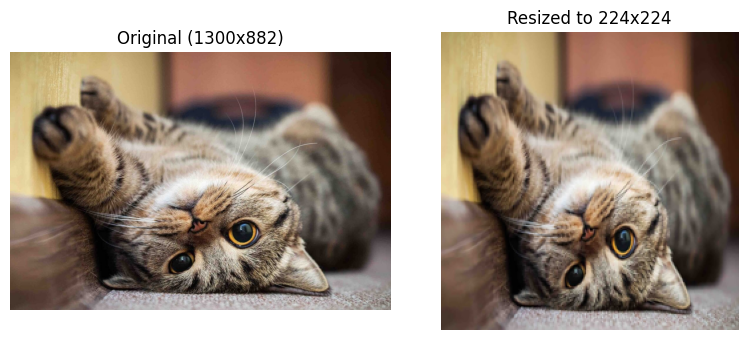

In [3]:
transform = weights.transforms()

img = Image.open("cute_cat.jpg").convert("RGB")
img_224 = img.resize((224, 224))
img_np = np.array(img_224)

x = transform(img).unsqueeze(0)  # (1, 3, 224, 224)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(np.array(img))
axes[0].set_title(f"Original ({img.size[0]}x{img.size[1]})")
axes[0].axis("off")
axes[1].imshow(img_np)
axes[1].set_title("Resized to 224x224")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### 1.4 Register Forward Hooks to Capture Attention

By default, `torchvision`'s ViT does **not** return attention weights. We use two tricks:

1. **Monkey-patch** each block's `self_attention.forward` to pass `need_weights=True` and `average_attn_weights=False`, so we get per-head weights.
2. **Register a forward hook** that intercepts the second output (the attention tensor) and stores it.

After a single forward pass, `attention_maps[l]` contains the attention tensor for layer $l$, with shape `(1, 12, 197, 197)` — that is *(batch, heads, query tokens, key tokens)*.

In [4]:
attention_maps = []


def attention_hook(module, input, output):
    attention_maps.append(output[1].detach())


for block in model.encoder.layers:
    original_forward = block.self_attention.forward

    def patched_forward(*args, _orig=original_forward, **kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False
        return _orig(*args, **kwargs)

    block.self_attention.forward = patched_forward
    block.self_attention.register_forward_hook(attention_hook)

with torch.no_grad():
    y = model(x)

print(f"Captured attention from {len(attention_maps)} layers.")
print(f"Shape per layer: {attention_maps[0].shape}  →  (batch, heads, tokens, tokens)")

Captured attention from 12 layers.
Shape per layer: torch.Size([1, 12, 197, 197])  →  (batch, heads, tokens, tokens)


---
## 2. Single-Layer CLS Attention Visualization

The **CLS token** (token 0) aggregates global information via attention. By examining row 0 of the attention matrix (columns 1–196), we can see **which patches the CLS token attends to** — effectively, what parts of the image the model considers important at each layer.

Steps for each map:
1. Take the attention matrix at layer $l$ → shape `(heads, 197, 197)`.
2. Select the CLS row (`attn[:, 0, :]`) and drop the CLS-to-CLS entry → `(heads, 196)`.
3. Either average across heads or pick one head.
4. Reshape to 14×14 (the spatial patch grid).
5. Bilinearly upsample to 224×224 and overlay as a heatmap.

In [5]:
def get_cls_attention_map(attn, head=None):
    """Extract a 224×224 CLS→patch attention heatmap from one layer's attention tensor."""
    attn = attn[0]  # remove batch dim → (heads, T, T)

    if head is None:
        attn = attn.mean(dim=0)  # average over heads → (T, T)
    else:
        attn = attn[head]  # pick one head → (T, T)

    cls_attn = attn[0, 1:]  # CLS row, drop CLS-to-CLS → (196,)
    heatmap = cls_attn.reshape(14, 14)
    heatmap = F.interpolate(
        heatmap[None, None], size=(224, 224), mode="bilinear", align_corners=False
    )
    return heatmap[0, 0].cpu().numpy()

### 2.1 Head-Averaged Attention Across Layers

We show the head-averaged CLS attention at layers 0, 3, 6, 9, and 11 to observe how the receptive field evolves with depth. Early layers tend to attend locally (edges, textures), while deeper layers attend to more semantically relevant regions.

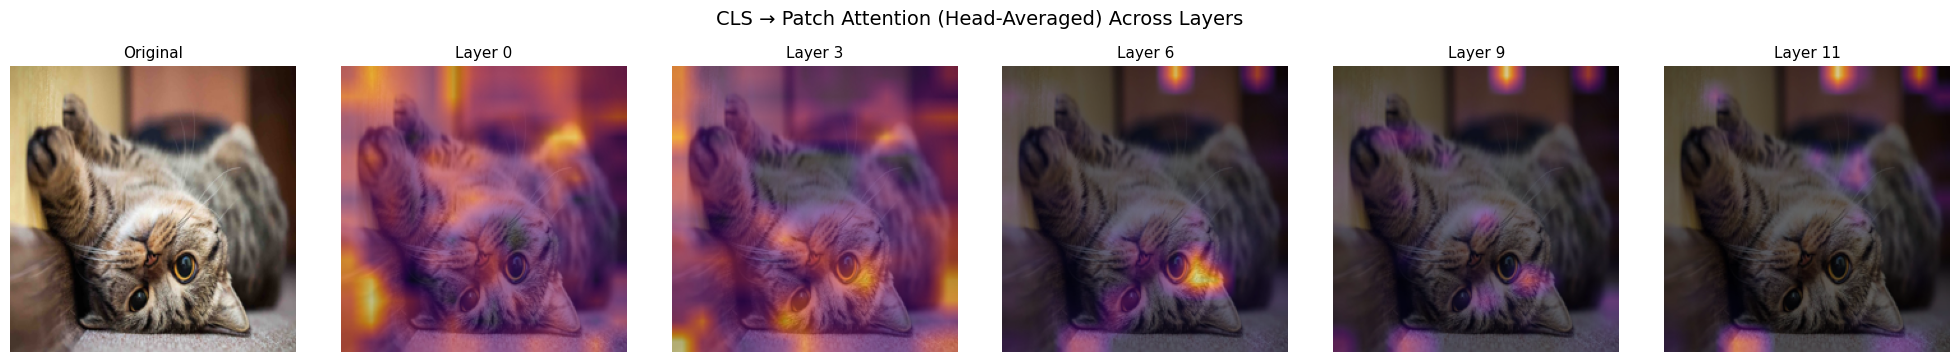

In [6]:
layers_to_show = [0, 3, 6, 9, 11]

fig, axes = plt.subplots(1, len(layers_to_show) + 1, figsize=(20, 3.5))

axes[0].imshow(img_np)
axes[0].set_title("Original", fontsize=11)
axes[0].axis("off")

for i, layer_idx in enumerate(layers_to_show):
    heatmap = get_cls_attention_map(attention_maps[layer_idx], head=None)
    axes[i + 1].imshow(img_np)
    axes[i + 1].imshow(heatmap, cmap="inferno", alpha=0.6)
    axes[i + 1].set_title(f"Layer {layer_idx}", fontsize=11)
    axes[i + 1].axis("off")

fig.suptitle("CLS → Patch Attention (Head-Averaged) Across Layers", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Per-Head Attention at a Late Layer

ViT-B/16 has 12 attention heads per layer. Different heads can specialize: some attend globally, some focus on the subject, and some may appear nearly uniform (possible redundancy). Let's visualize all 12 heads at the last encoder layer (layer 9).

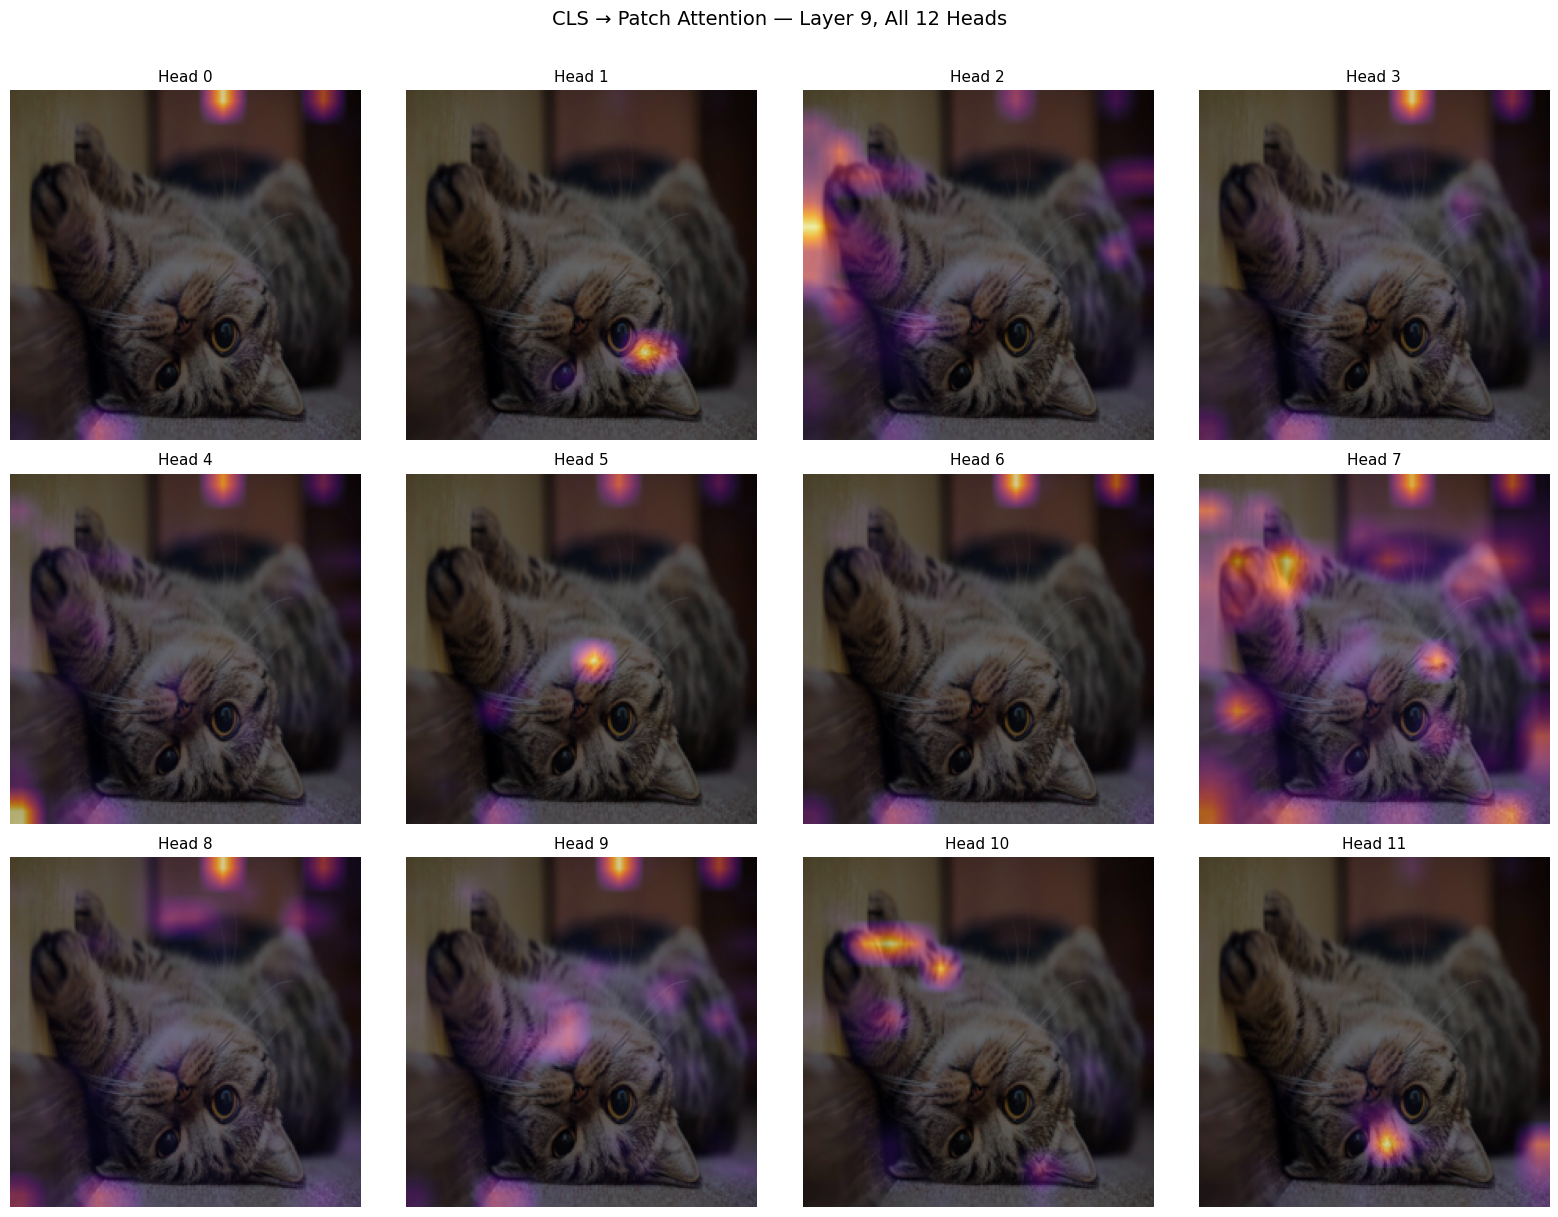

In [7]:
layer_idx = 9
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for head in range(12):
    ax = axes[head // 4, head % 4]
    heatmap = get_cls_attention_map(attention_maps[layer_idx], head=head)
    ax.imshow(img_np)
    ax.imshow(heatmap, cmap="inferno", alpha=0.6)
    ax.set_title(f"Head {head}", fontsize=11)
    ax.axis("off")

fig.suptitle(f"CLS → Patch Attention — Layer {layer_idx}, All 12 Heads", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Per-Head Attention at an Early Layer

For comparison, let's do the same for an early layer (layer 0). Early heads typically show more uniform or local patterns.

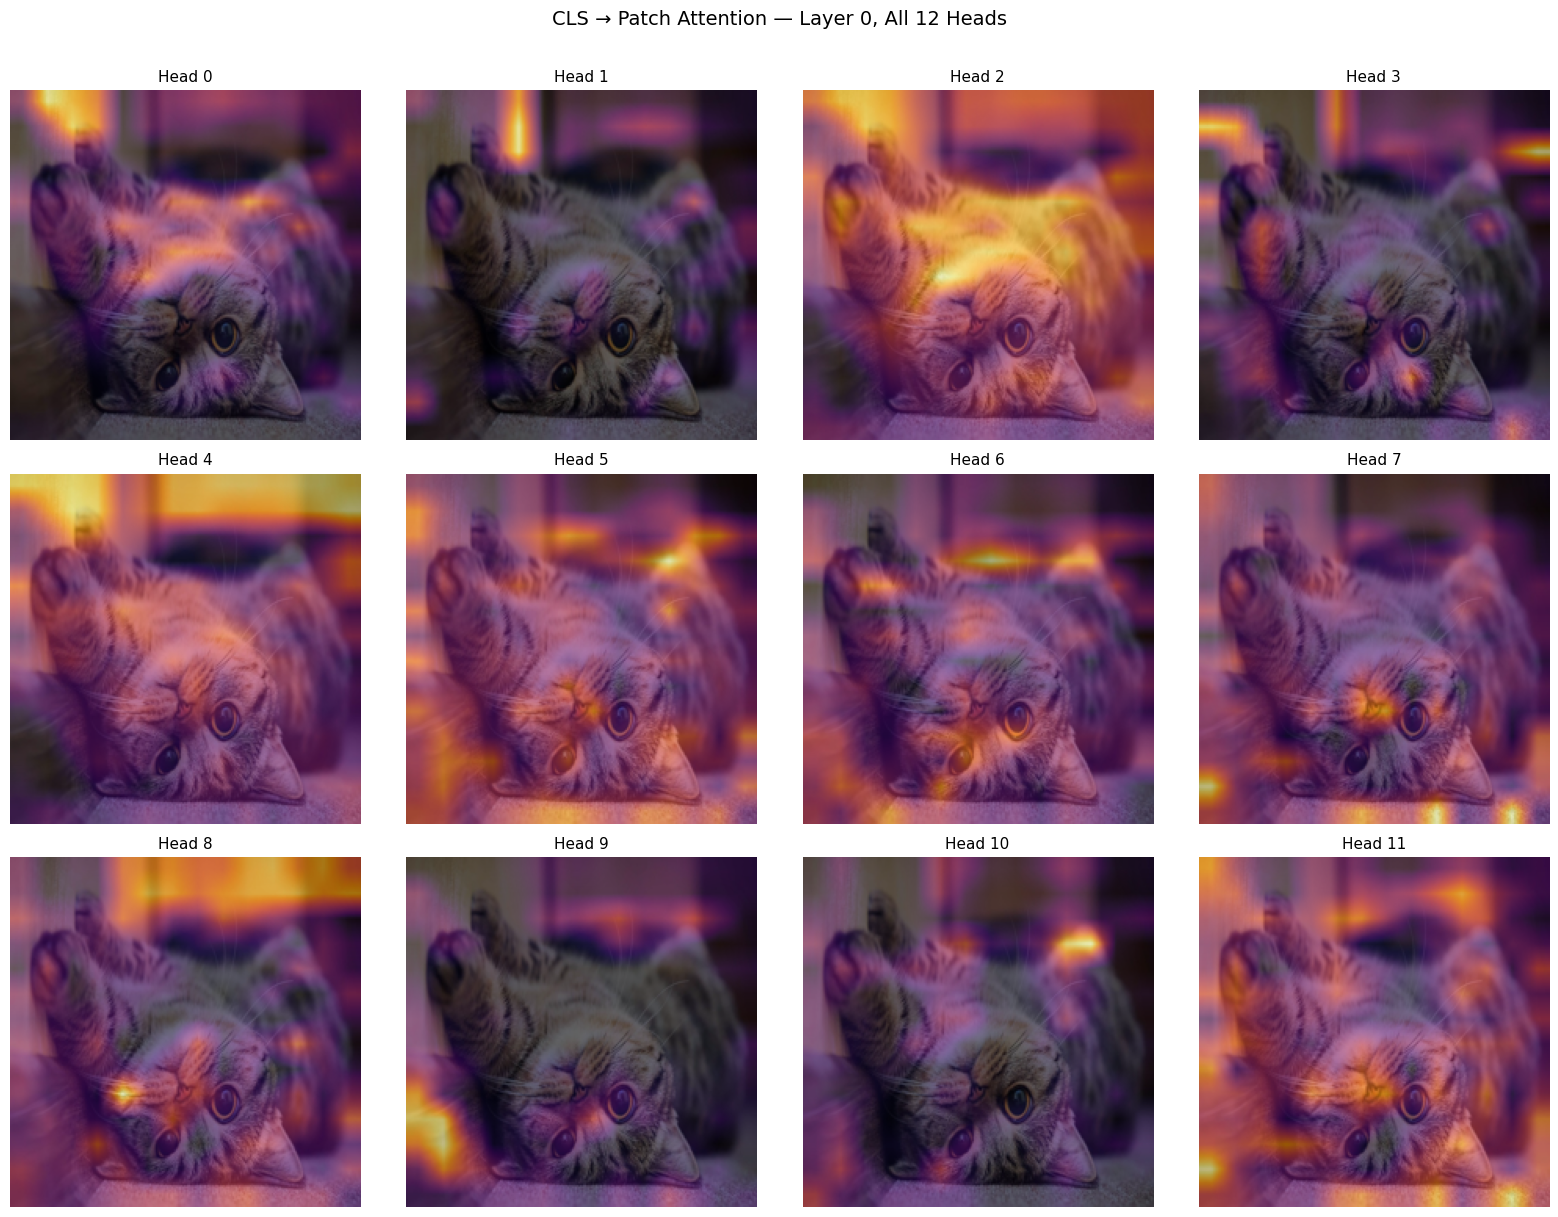

In [30]:
layer_idx = 0
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for head in range(12):
    ax = axes[head // 4, head % 4]
    heatmap = get_cls_attention_map(attention_maps[layer_idx], head=head)
    ax.imshow(img_np)
    ax.imshow(heatmap, cmap="inferno", alpha=0.6)
    ax.set_title(f"Head {head}", fontsize=11)
    ax.axis("off")

fig.suptitle(f"CLS → Patch Attention — Layer {layer_idx}, All 12 Heads", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Attention Entropy Per Head

To quantify whether a head is "sharp" (focused) or "diffuse" (uniform), we compute the **entropy** of the CLS attention distribution for every head at every layer. High entropy ≈ uniform attention; low entropy ≈ concentrated attention.

$$H = -\sum_i p_i \log p_i$$

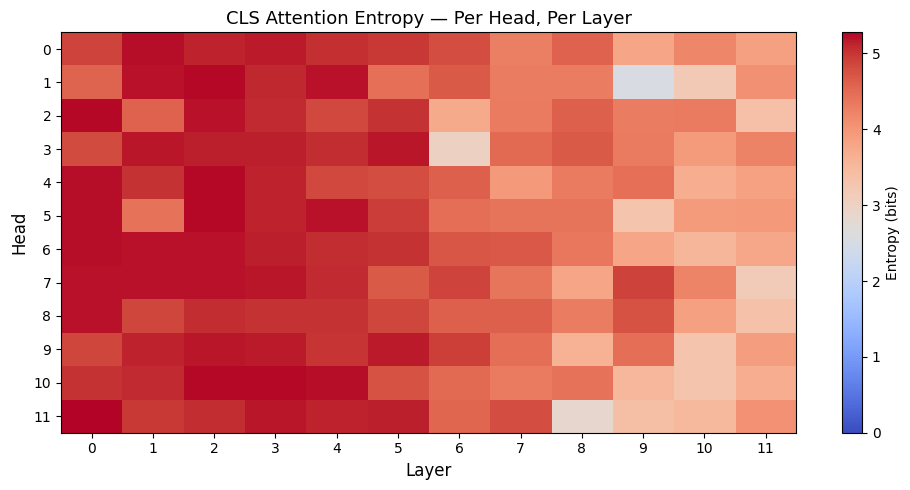

Max possible entropy (uniform over 196 patches): 5.28
Min observed entropy: 2.55 (layer 9)
Max observed entropy: 5.27 (layer 0)


In [31]:
num_layers = len(attention_maps)
num_heads = attention_maps[0].shape[1]

entropy_matrix = np.zeros((num_layers, num_heads))
for l in range(num_layers):
    attn = attention_maps[l][0]  # (H, T, T)
    cls_attn = attn[:, 0, 1:]    # (H, 196)
    cls_attn = cls_attn / cls_attn.sum(dim=-1, keepdim=True)  # re-normalize
    log_attn = torch.log(cls_attn + 1e-12)
    entropy = -(cls_attn * log_attn).sum(dim=-1)  # (H,)
    entropy_matrix[l] = entropy.numpy()

max_entropy = np.log(196)  # uniform distribution over 196 patches

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(entropy_matrix.T, aspect="auto", cmap="coolwarm", vmin=0, vmax=max_entropy)
ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("Head", fontsize=12)
ax.set_xticks(range(num_layers))
ax.set_yticks(range(num_heads))
fig.colorbar(im, ax=ax, label="Entropy (bits)")
ax.set_title("CLS Attention Entropy — Per Head, Per Layer", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Max possible entropy (uniform over 196 patches): {max_entropy:.2f}")
print(f"Min observed entropy: {entropy_matrix.min():.2f} (layer {entropy_matrix.min(axis=1).argmin()})")
print(f"Max observed entropy: {entropy_matrix.max():.2f} (layer {entropy_matrix.max(axis=1).argmax()})")

---
## 3. Attention Rollout

Single-layer attention maps only show **local** information flow (one hop). **Attention rollout** composes attention matrices across layers to estimate how information propagates from input patches to the final CLS token through the entire network.

**Algorithm:**
1. For each layer $l$, take the head-averaged attention matrix $A_l$ ∈ $\mathbb{R}^{T \times T}$.
2. Add the identity (residual connection): $\hat{A}_l = A_l + I$.
3. Re-normalize rows to sum to 1.
4. Compose: $R = \hat{A}_L \cdot \hat{A}_{L-1} \cdots \hat{A}_1$.
5. Row 0 of $R$ shows how much each patch contributed to the final CLS representation.

In [32]:
num_tokens = attention_maps[0].shape[-1]  # 197
rollout = torch.eye(num_tokens)
rollout_maps = []

for attn in attention_maps:
    attn_avg = attn[0].mean(dim=0)  # average over heads → (T, T)

    attn_aug = attn_avg + torch.eye(num_tokens)  # residual connection
    attn_aug = attn_aug / attn_aug.sum(dim=-1, keepdim=True)  # row-normalize

    rollout = attn_aug @ rollout
    rollout_maps.append(rollout.clone())

### 3.1 Rollout Progression Across Layers

We visualize the rollout map accumulated up to each selected layer. The rollout should become progressively **smoother** and more **semantically meaningful** as more layers are composed.

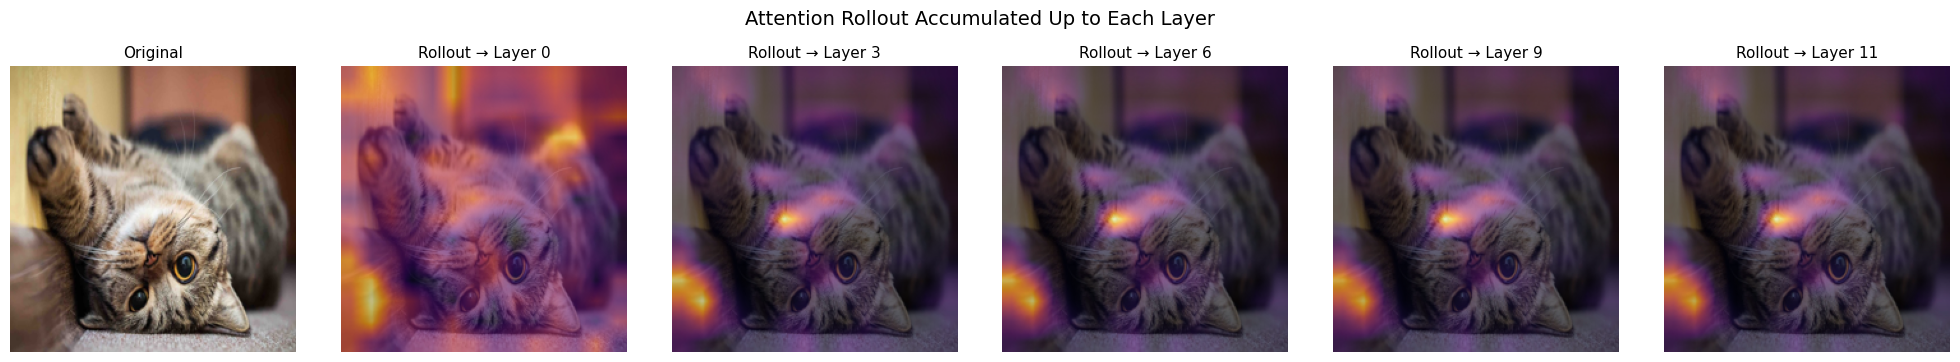

In [33]:
def get_cls_rollout_map(rollout_matrix):
    """Extract a 224×224 CLS rollout heatmap."""
    cls_rollout = rollout_matrix[0, 1:]  # CLS row, drop self
    cls_rollout = cls_rollout / cls_rollout.max()  # normalize to [0, 1]
    heatmap = cls_rollout.reshape(14, 14)
    heatmap = F.interpolate(
        heatmap[None, None], size=(224, 224), mode="bilinear", align_corners=False
    )
    return heatmap[0, 0].cpu().numpy()


layers_to_show = [0, 3, 6, 9, 11]

fig, axes = plt.subplots(1, len(layers_to_show) + 1, figsize=(20, 3.5))

axes[0].imshow(img_np)
axes[0].set_title("Original", fontsize=11)
axes[0].axis("off")

for i, layer_idx in enumerate(layers_to_show):
    heatmap = get_cls_rollout_map(rollout_maps[layer_idx])
    axes[i + 1].imshow(img_np)
    axes[i + 1].imshow(heatmap, cmap="inferno", alpha=0.6)
    axes[i + 1].set_title(f"Rollout → Layer {layer_idx}", fontsize=11)
    axes[i + 1].axis("off")

fig.suptitle("Attention Rollout Accumulated Up to Each Layer", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Single-Layer vs. Rollout Comparison

A side-by-side comparison at the final layer makes it easy to see the difference:
- **Single-layer** attention (layer 11) only shows direct one-hop attention.
- **Rollout** aggregates information flow through all 12 layers, giving a more holistic picture of what patches actually influence the CLS representation.

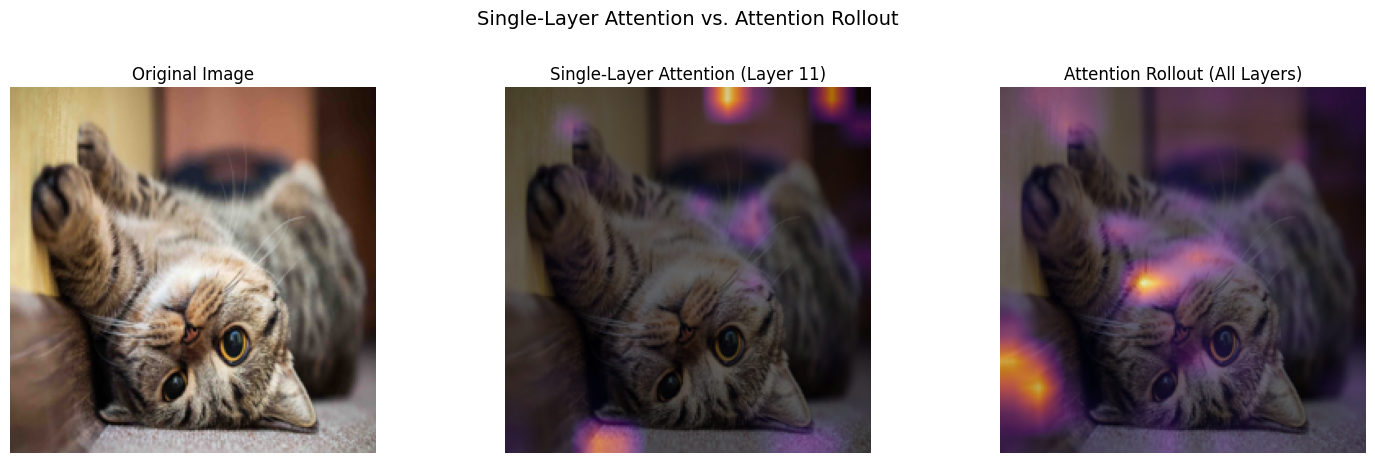

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].imshow(img_np)
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis("off")

single_layer = get_cls_attention_map(attention_maps[11], head=None)
axes[1].imshow(img_np)
axes[1].imshow(single_layer, cmap="inferno", alpha=0.6)
axes[1].set_title("Single-Layer Attention (Layer 11)", fontsize=12)
axes[1].axis("off")

rollout_final = get_cls_rollout_map(rollout_maps[11])
axes[2].imshow(img_np)
axes[2].imshow(rollout_final, cmap="inferno", alpha=0.6)
axes[2].set_title("Attention Rollout (All Layers)", fontsize=12)
axes[2].axis("off")

fig.suptitle("Single-Layer Attention vs. Attention Rollout", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- The rollout map tends to be **smoother** and more **spread out** than single-layer attention, because it accounts for information mixing across all layers.
- It often highlights the entire object rather than just a few salient patches, making it more **semantically meaningful**.
- Single-layer attention at deeper layers can be very **focused** but may miss context that was gathered in earlier layers.

---
## 4. Sinusoidal Positional Encodings

Transformers are **permutation-invariant** — self-attention treats the input as a set, not a sequence. Without positional information, swapping two patches would yield the same output. **Positional encodings** break this symmetry.

The sinusoidal encoding from *"Attention is All You Need"* (Vaswani et al., 2017) assigns each position a unique vector using sine and cosine functions at different frequencies:

$$PE(\text{pos}, 2i) = \sin\!\left(\frac{\text{pos}}{10000^{2i/d}}\right), \qquad PE(\text{pos}, 2i+1) = \cos\!\left(\frac{\text{pos}}{10000^{2i/d}}\right)$$

- **pos**: token position (0 to $T{-}1$)
- **i**: dimension index
- Lower dimensions oscillate slowly → capture coarse position; higher dimensions oscillate fast → capture fine position.

The encoding is added directly to the token embeddings: $Z = X + PE$.

### 4.1 Implementation

In [35]:
def sinusoidal_positional_encoding(seq_len, d_model):
    """Generate the sinusoidal positional encoding matrix.

    Returns:
        Tensor of shape (seq_len, d_model).
    """
    positions = torch.arange(seq_len).unsqueeze(1).float()          # (T, 1)
    dim_indices = torch.arange(0, d_model, 2).float()               # (d/2,)
    div_term = torch.exp(dim_indices * -(math.log(10000.0) / d_model))  # (d/2,)

    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(positions * div_term)   # even dims
    pe[:, 1::2] = torch.cos(positions * div_term)   # odd dims
    return pe


pe = sinusoidal_positional_encoding(seq_len=197, d_model=768)
print(f"Positional encoding shape: {pe.shape}  →  (tokens, embed_dim)")

Positional encoding shape: torch.Size([197, 768])  →  (tokens, embed_dim)


### 4.2 Visualize the Full Encoding Matrix

Each row is a position, each column is a dimension. We should see smooth wave-like patterns whose frequency increases with the dimension index.

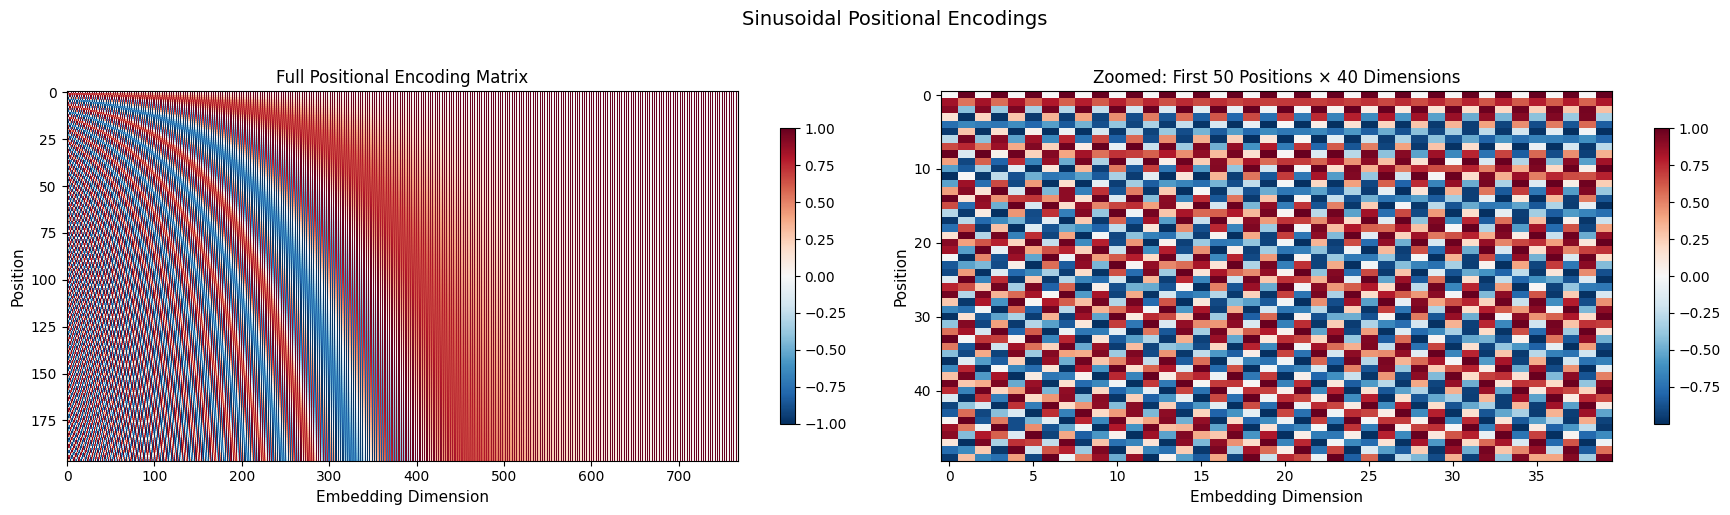

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

im0 = axes[0].imshow(pe.numpy(), aspect="auto", cmap="RdBu_r", interpolation="nearest")
axes[0].set_xlabel("Embedding Dimension", fontsize=11)
axes[0].set_ylabel("Position", fontsize=11)
axes[0].set_title("Full Positional Encoding Matrix", fontsize=12)
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Zoom into the first 40 dimensions to better see the wave patterns
im1 = axes[1].imshow(pe[:50, :40].numpy(), aspect="auto", cmap="RdBu_r", interpolation="nearest")
axes[1].set_xlabel("Embedding Dimension", fontsize=11)
axes[1].set_ylabel("Position", fontsize=11)
axes[1].set_title("Zoomed: First 50 Positions × 40 Dimensions", fontsize=12)
fig.colorbar(im1, ax=axes[1], shrink=0.8)

fig.suptitle("Sinusoidal Positional Encodings", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Positional Encoding Waveforms

To make the frequency structure even clearer, let's plot a few individual dimensions as 1D signals over positions. Low-index dimensions have long wavelengths, while high-index ones oscillate rapidly.

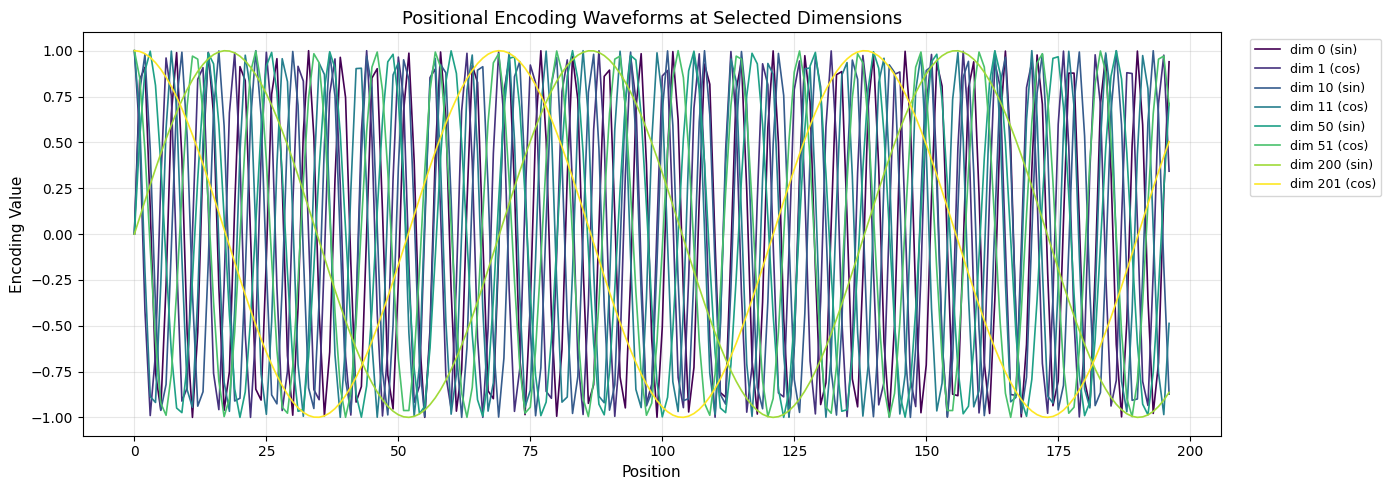

In [37]:
dims_to_plot = [0, 1, 10, 11, 50, 51, 200, 201]
colors = plt.cm.viridis(np.linspace(0, 1, len(dims_to_plot)))

fig, ax = plt.subplots(figsize=(14, 5))

for dim_idx, color in zip(dims_to_plot, colors):
    kind = "sin" if dim_idx % 2 == 0 else "cos"
    ax.plot(pe[:, dim_idx].numpy(), color=color, label=f"dim {dim_idx} ({kind})", linewidth=1.2)

ax.set_xlabel("Position", fontsize=11)
ax.set_ylabel("Encoding Value", fontsize=11)
ax.set_title("Positional Encoding Waveforms at Selected Dimensions", fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Cosine Similarity Between Positions

A key property of sinusoidal encodings is that **nearby positions have similar encodings** while distant positions diverge. We verify this by computing the pairwise cosine similarity matrix:

$$\text{sim}(i, j) = \frac{PE_i \cdot PE_j}{\|PE_i\| \, \|PE_j\|}$$

The result should show a clear diagonal band pattern — positions close together are highly similar.

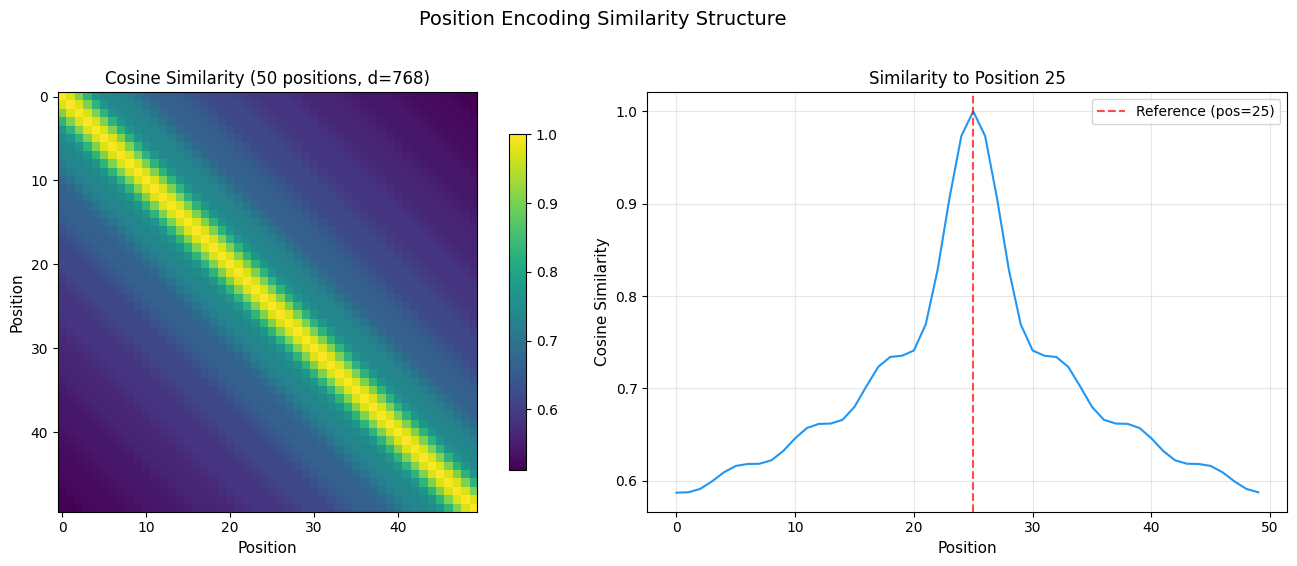

In [38]:
pe_small = sinusoidal_positional_encoding(seq_len=50, d_model=768)

pe_norm = pe_small / pe_small.norm(dim=1, keepdim=True)
similarity = pe_norm @ pe_norm.T

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

im0 = axes[0].imshow(similarity.numpy(), cmap="viridis")
axes[0].set_xlabel("Position", fontsize=11)
axes[0].set_ylabel("Position", fontsize=11)
axes[0].set_title("Cosine Similarity (50 positions, d=768)", fontsize=12)
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Also show how similarity decays with distance from a reference position
ref_pos = 25
axes[1].plot(similarity[ref_pos].numpy(), linewidth=1.5, color="#2196F3")
axes[1].axvline(ref_pos, color="red", linestyle="--", alpha=0.7, label=f"Reference (pos={ref_pos})")
axes[1].set_xlabel("Position", fontsize=11)
axes[1].set_ylabel("Cosine Similarity", fontsize=11)
axes[1].set_title(f"Similarity to Position {ref_pos}", fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Position Encoding Similarity Structure", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Effect of Embedding Dimension

Let's see how different embedding dimensions affect the similarity structure. Larger dimensions should provide better discrimination between positions.

C:\Users\Andreea\AppData\Local\Temp\ipykernel_14004\3671485272.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


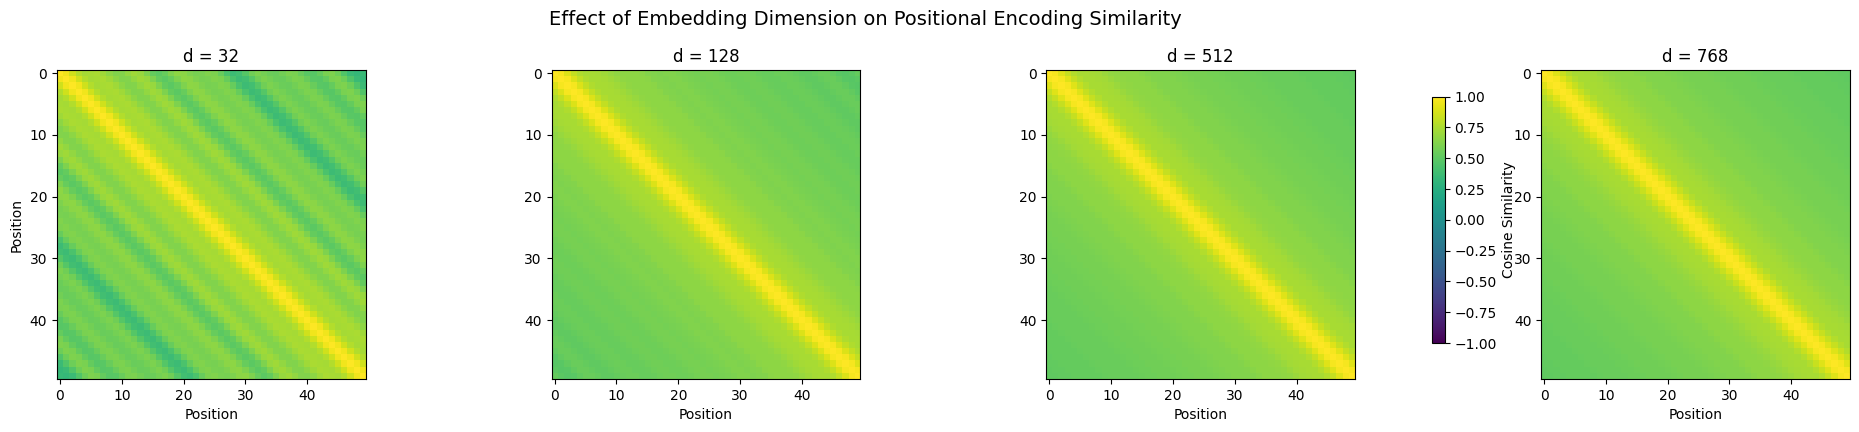

In [39]:
d_models = [32, 128, 512, 768]
seq_len = 50
ref_pos = 25

fig, axes = plt.subplots(1, len(d_models), figsize=(20, 4))

for i, d in enumerate(d_models):
    pe_d = sinusoidal_positional_encoding(seq_len, d)
    pe_d_norm = pe_d / pe_d.norm(dim=1, keepdim=True)
    sim = (pe_d_norm @ pe_d_norm.T).numpy()

    im = axes[i].imshow(sim, cmap="viridis", vmin=-1, vmax=1)
    axes[i].set_title(f"d = {d}", fontsize=12)
    axes[i].set_xlabel("Position")
    if i == 0:
        axes[i].set_ylabel("Position")

fig.colorbar(im, ax=axes, shrink=0.8, label="Cosine Similarity")
fig.suptitle("Effect of Embedding Dimension on Positional Encoding Similarity", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- With small $d$, many positions look similar, reducing the model's ability to distinguish them.
- Larger $d$ produces a sharper diagonal — each position gets a more unique encoding.
- At $d = 768$ (ViT-B/16's actual embedding dimension), positions are well-separated, with similarity decaying smoothly with distance.